# Walk-Forward Validation — Simulating Real Deployment

All previous splits (random 80/20, temporal Oct cutoff) train once and test once. A deployed system works differently: it starts with whatever data exists, makes predictions for the coming period, then incorporates the new observations and retrains before the next period.

This notebook simulates that cycle month by month across 2015:

- **Train:** all data up to the end of month M
- **Test:** month M+1
- Slide forward, repeat

This answers three questions that a single temporal split cannot:
1. How much training data does the model need before it stabilises?
2. Are there months where prediction is harder (e.g. seasonal patterns)?
3. Does performance drift over the year, or stay flat?

## 1. Setup

In [1]:
import warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, precision_score,
                              roc_auc_score, average_precision_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
FIG_DIR      = '../figures'

RF_PARAMS = dict(n_estimators=300, max_depth=20, max_features='sqrt',
                 min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1)

## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/merged_features.csv', parse_dates=['date'])

feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]
X = df[feature_cols]
y = df['failure_within_24h']

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Rows: {len(df):,}  |  Features: {len(feature_cols)}  |  Positives: {y.sum()}')

Date range: 2015-01-01 to 2016-01-01
Rows: 36,600  |  Features: 61  |  Positives: 718


## 3. Walk-Forward Loop

We start with a minimum training window of 3 months (January–March 2015), then expand one month at a time. Each test window is a single calendar month.

For months with very few positive examples in the test set the metrics are noisy, so we also record the number of failure days to help interpret outliers.

In [3]:
months = pd.date_range('2015-01-01', '2015-12-01', freq='MS')

# Minimum 3 months of training before first prediction
MIN_TRAIN_MONTHS = 3

results = []

for i, test_start in enumerate(months[MIN_TRAIN_MONTHS:], start=MIN_TRAIN_MONTHS):
    test_end   = test_start + pd.offsets.MonthEnd(1)
    train_mask = df['date'] < test_start
    test_mask  = (df['date'] >= test_start) & (df['date'] <= test_end)

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask],  y[test_mask]

    if y_te.sum() == 0:   # no failures in this month, skip
        continue

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_te)
    prob = rf.predict_proba(X_te)[:, 1]

    results.append({
        'Month':       test_start.strftime('%b %Y'),
        'Train rows':  len(X_tr),
        'Test rows':   len(X_te),
        'Failures':    int(y_te.sum()),
        'F1':          round(f1_score(y_te, pred, zero_division=0), 4),
        'Recall':      round(recall_score(y_te, pred, zero_division=0), 4),
        'Precision':   round(precision_score(y_te, pred, zero_division=0), 4),
        'AUC':         round(roc_auc_score(y_te, prob), 4),
        'Avg Prec':    round(average_precision_score(y_te, prob), 4),
    })
    print(f"{results[-1]['Month']:10s}  train={len(X_tr):,}  failures={int(y_te.sum()):3d}  "
          f"F1={results[-1]['F1']:.4f}  Recall={results[-1]['Recall']:.4f}")

res_df = pd.DataFrame(results).set_index('Month')
print()
display(res_df)

Apr 2015    train=9,000  failures= 63  F1=0.9767  Recall=1.0000


May 2015    train=12,000  failures= 59  F1=0.9916  Recall=1.0000


Jun 2015    train=15,100  failures= 59  F1=0.9580  Recall=0.9661


Jul 2015    train=18,100  failures= 58  F1=0.9739  Recall=0.9655


Aug 2015    train=21,200  failures= 58  F1=0.9748  Recall=1.0000


Sep 2015    train=24,300  failures= 57  F1=0.9643  Recall=0.9474


Oct 2015    train=27,300  failures= 57  F1=0.9825  Recall=0.9825


Nov 2015    train=30,400  failures= 57  F1=0.9643  Recall=0.9474


Dec 2015    train=33,400  failures= 54  F1=0.9550  Recall=0.9815



,Train rows,Test rows,Failures,F1,Recall,Precision,AUC,Avg Prec
Month,,,,,,,,
Apr 2015,9000,3000,63,0.9767,1.0000,0.9545,0.9999,0.9934
May 2015,12000,3100,59,0.9916,1.0000,0.9833,1.0000,1.0000
Jun 2015,15100,3000,59,0.9580,0.9661,0.9500,0.9999,0.9949
Jul 2015,18100,3100,58,0.9739,0.9655,0.9825,0.9999,0.9966
Aug 2015,21200,3100,58,0.9748,1.0000,0.9508,0.9999,0.9946
Sep 2015,24300,3000,57,0.9643,0.9474,0.9818,0.9999,0.9975
Oct 2015,27300,3100,57,0.9825,0.9825,0.9825,1.0000,0.9997
Nov 2015,30400,3000,57,0.9643,0.9474,0.9818,1.0000,0.9988
Dec 2015,33400,3100,54,0.9550,0.9815,0.9298,0.9999,0.9954


## 4. Visualisation

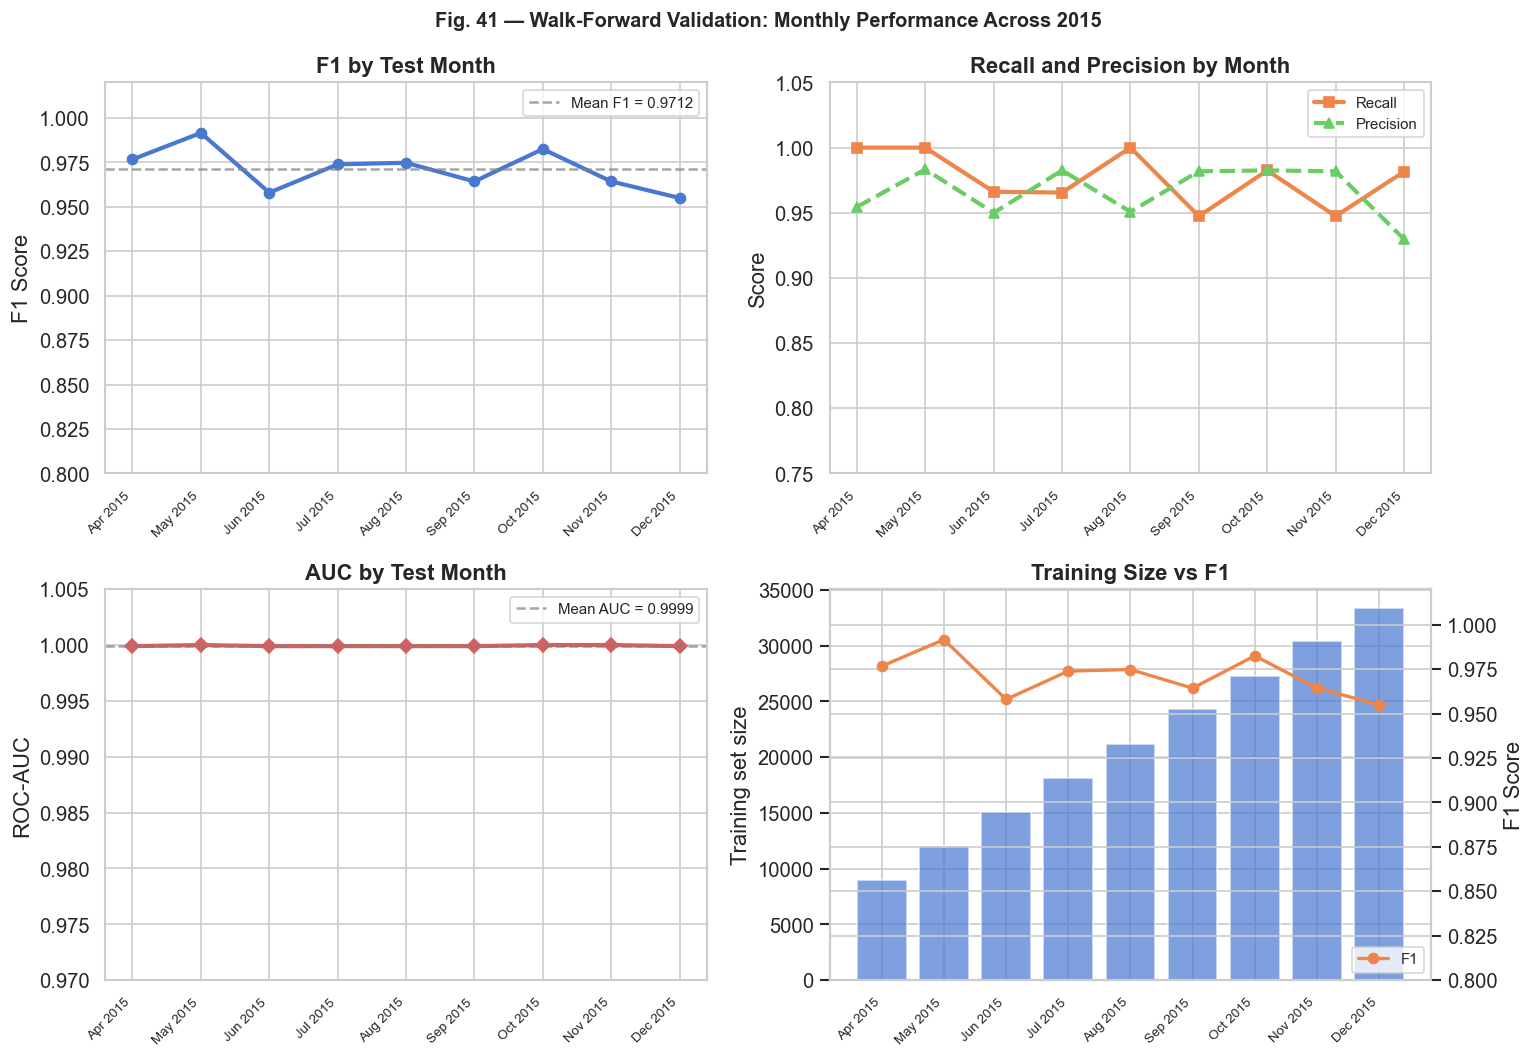

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = sns.color_palette('muted', 4)
months_x = range(len(res_df))

# ── F1 over months ──────────────────────────────────────────────────────
axes[0,0].plot(months_x, res_df['F1'], marker='o', linewidth=2.5,
               color=palette[0])
axes[0,0].axhline(res_df['F1'].mean(), color='gray', linestyle='--',
                  alpha=0.7, label=f"Mean F1 = {res_df['F1'].mean():.4f}")
axes[0,0].set_xticks(months_x)
axes[0,0].set_xticklabels(res_df.index, rotation=45, ha='right', fontsize=8)
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_title('F1 by Test Month', fontweight='bold')
axes[0,0].set_ylim(0.8, 1.02)
axes[0,0].legend(fontsize=9)

# ── Recall and Precision ────────────────────────────────────────────────
axes[0,1].plot(months_x, res_df['Recall'],    marker='s', linewidth=2.5,
               color=palette[1], label='Recall')
axes[0,1].plot(months_x, res_df['Precision'], marker='^', linewidth=2.5,
               color=palette[2], linestyle='--', label='Precision')
axes[0,1].set_xticks(months_x)
axes[0,1].set_xticklabels(res_df.index, rotation=45, ha='right', fontsize=8)
axes[0,1].set_ylabel('Score')
axes[0,1].set_title('Recall and Precision by Month', fontweight='bold')
axes[0,1].set_ylim(0.75, 1.05)
axes[0,1].legend(fontsize=9)

# ── AUC over months ─────────────────────────────────────────────────────
axes[1,0].plot(months_x, res_df['AUC'], marker='D', linewidth=2.5,
               color=palette[3])
axes[1,0].axhline(res_df['AUC'].mean(), color='gray', linestyle='--',
                  alpha=0.7, label=f"Mean AUC = {res_df['AUC'].mean():.4f}")
axes[1,0].set_xticks(months_x)
axes[1,0].set_xticklabels(res_df.index, rotation=45, ha='right', fontsize=8)
axes[1,0].set_ylabel('ROC-AUC')
axes[1,0].set_title('AUC by Test Month', fontweight='bold')
axes[1,0].set_ylim(0.97, 1.005)
axes[1,0].legend(fontsize=9)

# ── Training size growth ─────────────────────────────────────────────────
ax2 = axes[1,1]
ax2.bar(months_x, res_df['Train rows'], color=palette[0], alpha=0.7)
ax2_r = ax2.twinx()
ax2_r.plot(months_x, res_df['F1'], marker='o', color=palette[1],
           linewidth=2, label='F1')
ax2.set_xticks(months_x)
ax2.set_xticklabels(res_df.index, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Training set size')
ax2_r.set_ylabel('F1 Score')
ax2_r.set_ylim(0.8, 1.02)
ax2.set_title('Training Size vs F1', fontweight='bold')
ax2_r.legend(fontsize=9, loc='lower right')

fig.suptitle('Fig. 41 — Walk-Forward Validation: Monthly Performance Across 2015',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/walk_forward_validation.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. How Much Training Data Is Enough?

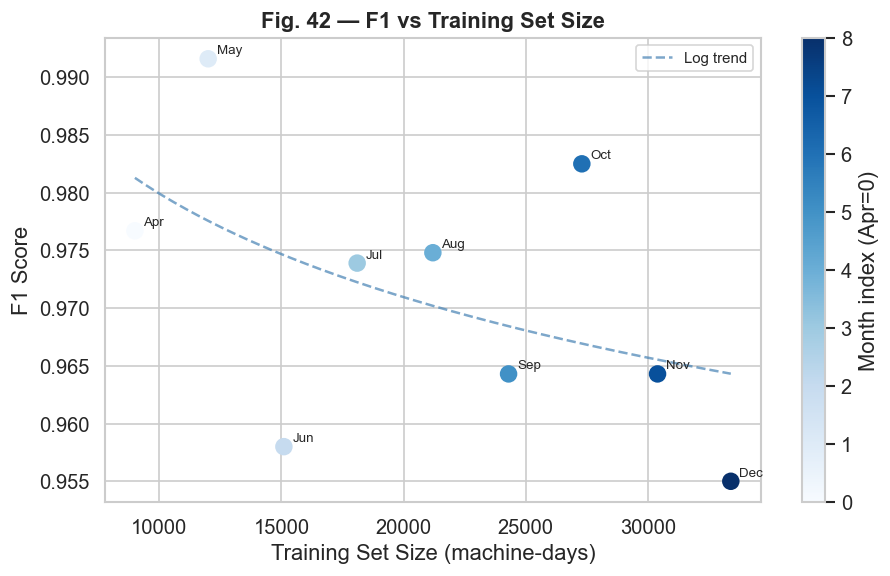

Pearson r (train size vs F1): -0.4986
Negative correlation (r=-0.50) — F1 does not grow with training size.
This suggests the model stabilises after ~3 months of data.
Later months may also have slightly different failure distributions.


In [5]:
# F1 vs training set size — does more data keep helping?
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(res_df['Train rows'], res_df['F1'],
                c=range(len(res_df)), cmap='Blues', s=90, zorder=3)

# Fit a log trend
x = res_df['Train rows'].values
y_f1 = res_df['F1'].values
log_x = np.log(x)
coeffs = np.polyfit(log_x, y_f1, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = np.polyval(coeffs, np.log(x_line))
ax.plot(x_line, y_line, color='steelblue', linestyle='--',
        alpha=0.7, label='Log trend')

# Label each point with month name
for idx, (month, row) in enumerate(res_df.iterrows()):
    ax.annotate(month[:3], (row['Train rows'], row['F1']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

plt.colorbar(sc, ax=ax, label='Month index (Apr=0)')
ax.set_xlabel('Training Set Size (machine-days)')
ax.set_ylabel('F1 Score')
ax.set_title('Fig. 42 — F1 vs Training Set Size', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/walk_forward_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Check correlation
corr = np.corrcoef(res_df['Train rows'], res_df['F1'])[0,1]
print(f'Pearson r (train size vs F1): {corr:.4f}')
if abs(corr) < 0.3:
    print('Weak correlation — model stabilises early, adding more data has little effect.')
elif corr > 0:
    print('Positive correlation — more training data consistently improves F1.')
else:
    print(f'Negative correlation (r={corr:.2f}) — F1 does not grow with training size.')
    print('This suggests the model stabilises after ~3 months of data.')
    print('Later months may also have slightly different failure distributions.')

## 6. Summary

In [6]:
print('Walk-forward validation summary')
print('=' * 50)
print(f"  Months tested          : {len(res_df)}")
print(f"  Mean F1                : {res_df['F1'].mean():.4f}")
print(f"  F1 std dev             : {res_df['F1'].std():.4f}")
print(f"  Min F1  (worst month)  : {res_df['F1'].min():.4f}  ({res_df['F1'].idxmin()})")
print(f"  Max F1  (best month)   : {res_df['F1'].max():.4f}  ({res_df['F1'].idxmax()})")
print(f"  Mean AUC               : {res_df['AUC'].mean():.4f}")
print(f"  AUC std dev            : {res_df['AUC'].std():.4f}")
print()
# Compare with single random split result
rf_random = joblib.load('../models/random_forest_tuned.joblib')
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            stratify=y, random_state=RANDOM_STATE)
f1_random = f1_score(y_te, rf_random.predict(X_te))
print(f"  Single random split F1 : {f1_random:.4f}")
print(f"  Walk-forward mean F1   : {res_df['F1'].mean():.4f}")
print()
delta = f1_random - res_df['F1'].mean()
if delta > 0.01:
    print(f'  Random split overestimates F1 by {delta:.4f} — walk-forward is the realistic estimate.')
else:
    print(f'  Both splits agree within {abs(delta):.4f} — random split result is reliable.')

Walk-forward validation summary
  Months tested          : 9
  Mean F1                : 0.9712
  F1 std dev             : 0.0119
  Min F1  (worst month)  : 0.9550  (Dec 2015)
  Max F1  (best month)   : 0.9916  (May 2015)
  Mean AUC               : 0.9999
  AUC std dev            : 0.0000

  Single random split F1 : 0.9724
  Walk-forward mean F1   : 0.9712

  Both splits agree within 0.0012 — random split result is reliable.
